In [35]:
import os 
import pandas as pd
import numpy as np

**Task 1: Dataset Exploration**

In [36]:
from tensorflow.keras.datasets import fashion_mnist

In [37]:
os.makedirs("plots", exist_ok=True)

In [38]:

CLASS_NAMES = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
]

In [39]:
def save_plot(filename):
    plt.savefig(
        filename,
        format="png",
        dpi=600,
        bbox_inches="tight",
    )

In [40]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [41]:
print("\nTraining Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("\nTesting Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

print("\nImage Shape :", x_train[0].shape)


Training Images : (60000, 28, 28)
Training Labels : (60000,)

Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)

Image Shape : (28, 28)


Displaying Sample Images...


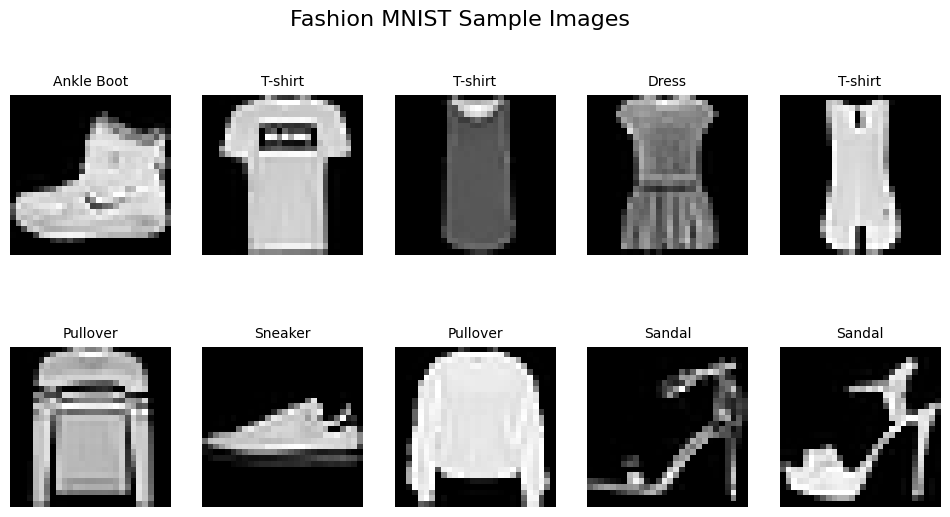

In [42]:
import matplotlib.pyplot as plt
print("Displaying Sample Images...")

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    ax.imshow(x_train[i], cmap="gray")

    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=10)

    ax.axis("off")

plt.suptitle("Fashion MNIST Sample Images", fontsize=16)

save_plot("plots/sample_images.png")

plt.show()

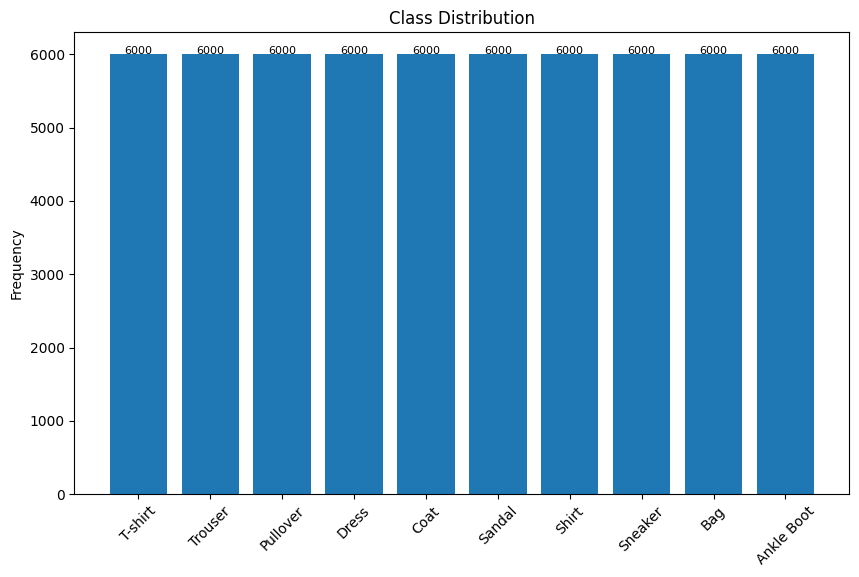

In [43]:
plt.figure(figsize=(10, 6))

counts = np.bincount(y_train)

bars = plt.bar(CLASS_NAMES, counts)

plt.xticks(rotation=45)

plt.ylabel("Frequency")

plt.title("Class Distribution")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(bar.get_height()),
        ha="center",
        fontsize=8,
    )

save_plot("plots/class_distribution.png")

plt.show()

**Task 2: Data Preprocessing**

In [44]:
print("\nOriginal Shape")

print("Train :", x_train.shape)

print("Test  :", x_test.shape)


Original Shape
Train : (60000, 28, 28)
Test  : (10000, 28, 28)


In [45]:
x_train_flat = x_train.reshape(-1, 784)

x_test_flat = x_test.reshape(-1, 784)

In [46]:
print("Flattened Shape")

print("Train :", x_train_flat.shape)

print("Test  :", x_test_flat.shape)


Flattened Shape
Train : (60000, 784)
Test  : (10000, 784)


In [47]:
# Fattening the input images 
x_train_flat = x_train_flat.astype("float32") / 255.0
x_test_flat = x_test_flat.astype("float32") / 255.0

In [48]:
x_train_flat[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [49]:
print("Pixel Range")
print("Minimum :", np.min(x_train_flat))
print("Maximum :", np.max(x_train_flat))

Pixel Range
Minimum : 0.0
Maximum : 1.0


In [50]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
print("One Hot Label Shape")
print(y_train_cat.shape)

One Hot Label Shape
(60000, 10)


**Task 3: Model Construction**

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(
    128,
    activation="relu"),
     Dense(
    64,
    activation="relu"),
     Dense(
    10,
    activation="softmax"),
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Model Training**

In [52]:
print("Model traning")
import time
start = time.time()
history = baseline_model.fit(x_train_flat,y_train_cat,epochs=20,batch_size=32,validation_split=0.2,verbose=1)

baseline_training_time = time.time() - start
print("Training Time : %.2f seconds" % baseline_training_time)

Model traning
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8177 - loss: 0.5109 - val_accuracy: 0.8559 - val_loss: 0.4044
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8640 - loss: 0.3741 - val_accuracy: 0.8605 - val_loss: 0.3786
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8762 - loss: 0.3359 - val_accuracy: 0.8675 - val_loss: 0.3648
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8851 - loss: 0.3107 - val_accuracy: 0.8719 - val_loss: 0.3601
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8912 - loss: 0.2920 - val_accuracy: 0.8726 - val_loss: 0.3647
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8961 - loss: 0.2762 - val_accuracy: 0.8705 - val_loss: 0.3687
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9025 - loss: 0.2589 - val_accuracy: 0.8677 - val_loss: 0.3801
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9065 - l

**Task 5: Model Evaluation**

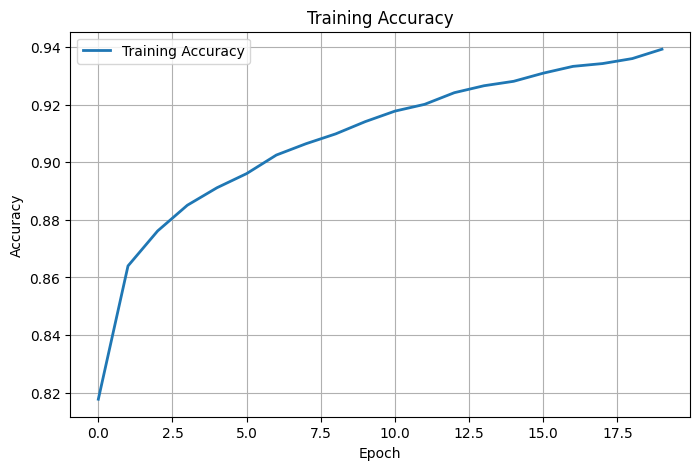

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(

    history.history["accuracy"],

    linewidth=2,

    label="Training Accuracy",

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.legend()

save_plot("plots/training_accuracy.png")

plt.show()

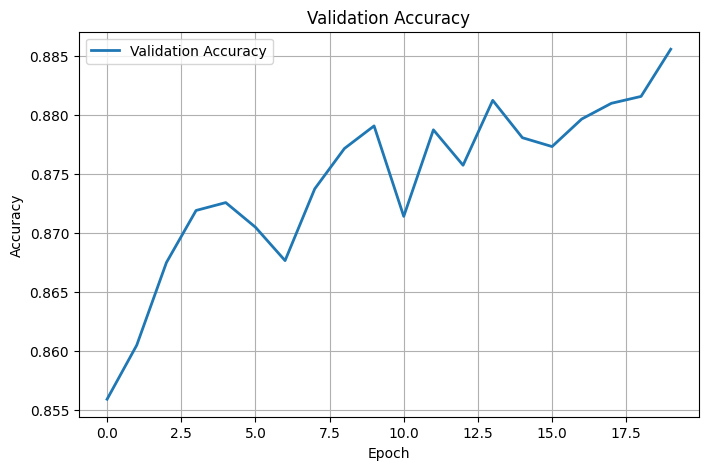

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(

    history.history["val_accuracy"],

    linewidth=2,

    label="Validation Accuracy",

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Validation Accuracy")

plt.grid(True)

plt.legend()

save_plot("plots/validation_accuracy.png")

plt.show()

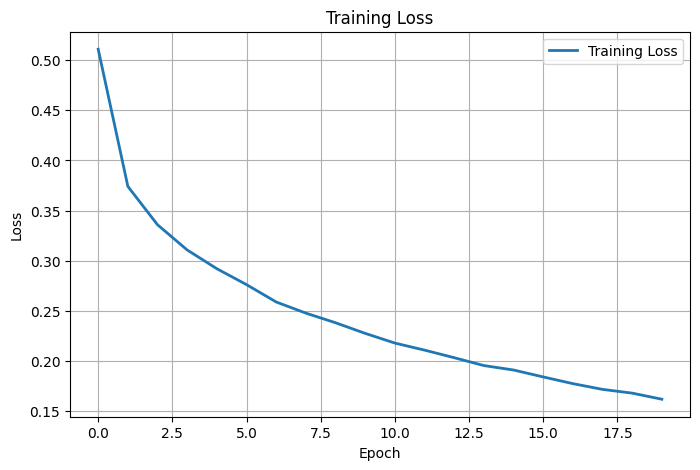

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(

    history.history["loss"],

    linewidth=2,

    label="Training Loss",

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.legend()

save_plot("plots/training_loss.png")

plt.show()

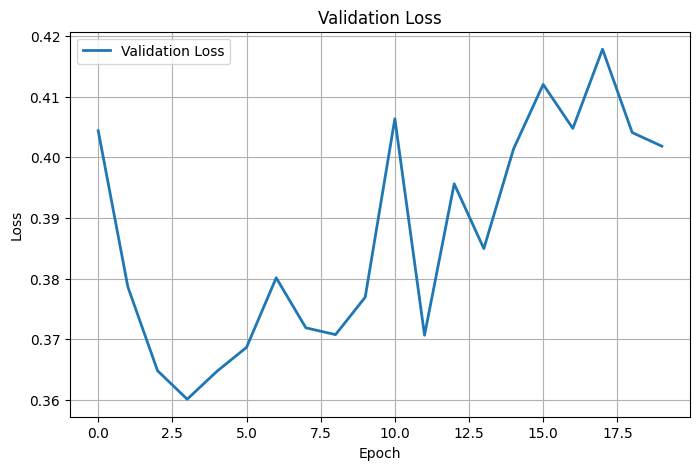

In [56]:

plt.figure(figsize=(8, 5))

plt.plot(

    history.history["val_loss"],

    linewidth=2,

    label="Validation Loss",

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Validation Loss")

plt.grid(True)

plt.legend()

save_plot("plots/validation_loss.png")

plt.show()


In [57]:
loss, accuracy = baseline_model.evaluate(

    x_test_flat,

    y_test_cat,

    verbose=0,

)

print("\nTest Accuracy : %.4f" % accuracy)



Test Accuracy : 0.8760


In [58]:
probabilities = baseline_model.predict(x_test_flat)

y_pred = np.argmax(probabilities, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

baseline_accuracy = accuracy_score(y_test, y_pred)

baseline_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
)

baseline_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
)

baseline_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",

)

print("\nAccuracy  :", baseline_accuracy)
print("Precision :", baseline_precision)
print("Recall    :", baseline_recall)
print("F1 Score  :", baseline_f1)


Accuracy  : 0.876
Precision : 0.8787250342438135
Recall    : 0.876
F1 Score  : 0.8764889599012102


In [60]:
print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
    )
)



Classification Report

              precision    recall  f1-score   support

     T-shirt       0.87      0.77      0.81      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.78      0.78      0.78      1000
       Dress       0.91      0.87      0.89      1000
        Coat       0.74      0.84      0.79      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.68      0.69      0.69      1000
     Sneaker       0.91      0.97      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle Boot       0.98      0.92      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



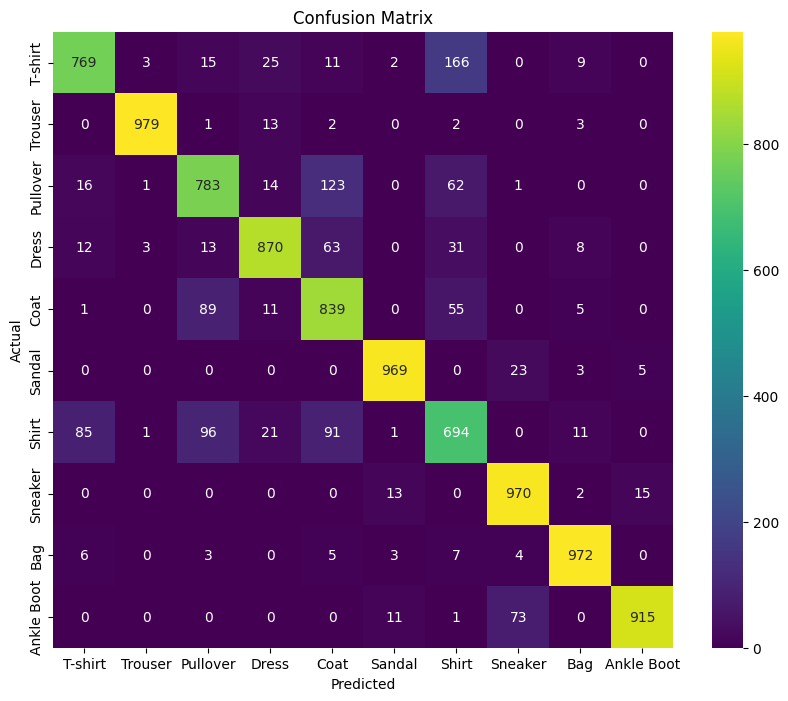

In [61]:
import seaborn as sns
cm = confusion_matrix(
    y_test,
    y_pred,
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
save_plot("plots/confusion_matrix.png")
plt.show()


In [62]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

In [63]:
import tensorflow as tf
def build_model(
    hidden_layers=2,
    neurons=128,
    learning_rate=0.001,
    optimizer="adam",
    activation="relu",
    dropout_rate=0.0,
):

    model = Sequential()
    model.add(Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(
            Dense(
                neurons,
                activation=activation,
            )
        )

        if dropout_rate > 0:
            model.add(
                tf.keras.layers.Dropout(dropout_rate)
            )

    model.add(
        Dense(
            10,
            activation="softmax",
        )
    )

    optimizer = optimizer.lower()

    if optimizer == "adam":
        opt = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    elif optimizer == "sgd":
        opt = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )
    else:
        opt = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [64]:
keras_classifier = KerasClassifier(
    model=build_model,
    verbose=0,
)


In [65]:
param_distributions = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer": ["adam", "sgd", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
}

In [66]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



In [67]:
random_search = RandomizedSearchCV(
    estimator=keras_classifier,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=SEED,
    verbose=2,
    n_jobs=-1,
)


In [69]:
search_start = time.time()
random_search.fit(
    x_train_flat,
    y_train_cat,
)

search_time = time.time() - search_start

Fitting 5 folds for each of 20 candidates, totalling 100 fits


I0000 00:00:1784639506.543388   29958 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12816 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784639506.552516   29958 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13624 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784639506.774383   29957 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12814 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784639506.776451   29957 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13348 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784639506.790679   29955 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:

[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time= 1.3min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time= 1.2min
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=128, model__optimizer=rmsprop; total time= 2.5min
[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=32, model__optimizer=rmsprop; total time= 3.7min
[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=128, model__optimizer=sgd; total time= 3.5min
[CV] EN

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
I0000 00:00:1784640622.315906   40005 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11208 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784640622.319177   40005 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13348 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784640627.282835   40101 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time= 1.3min
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=128, model__optimizer=rmsprop; total time= 2.5min
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=128, model__optimizer=rmsprop; total time= 2.5min
[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=32, model__optimizer=rmsprop; total time= 3.7min
[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=128, model__optimizer=sgd; total time= 3.4min


...

I0000 00:00:1784641297.885734   45787 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11216 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784641297.892504   45787 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13348 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784641305.350813   45941 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=sgd; total time= 1.3min
[CV] END batch_size=16, epochs=10, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=128, model__optimizer=rmsprop; total time= 2.6min
[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=32, model__optimizer=rmsprop; total time= 3.9min
[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=128, model__optimizer=sgd; total time= 3.3min
[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=128, model__optimizer=sgd; total time= 3.4min
[CV] END 

I0000 00:00:1784641389.303256   48017 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12488 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784641389.307415   48017 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13552 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784641391.444170   48044 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12122 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784641391.447292   48044 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13450 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784641393.715411   48170 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at mos

[CV] END batch_size=128, epochs=30, model__activation=sigmoid, model__dropout_rate=0.5, model__hidden_layers=3, model__learning_rate=0.1, model__neurons=128, model__optimizer=rmsprop; total time= 1.1min
[CV] END batch_size=128, epochs=30, model__activation=sigmoid, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.01, model__neurons=256, model__optimizer=rmsprop; total time=  58.2s
[CV] END batch_size=128, epochs=30, model__activation=tanh, model__dropout_rate=0.0, model__hidden_layers=3, model__learning_rate=0.01, model__neurons=256, model__optimizer=rmsprop; total time=  59.2s
[CV] END batch_size=64, epochs=30, model__activation=tanh, model__dropout_rate=0.5, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=128, model__optimizer=adam; total time= 1.8min
[CV] END batch_size=64, epochs=30, model__activation=tanh, model__dropout_rate=0.5, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=128, model__optimizer=adam; total time= 1.7min


I0000 00:00:1784642271.277785   57569 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11208 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784642271.280616   57569 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13348 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784642277.593880   57694 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [70]:
print("Best Cross Validation Accuracy")
print(random_search.best_score_)
print("Best Parameters")
for key, value in random_search.best_params_.items():
    print(f"{key:<30}: {value}")
print("Search Time")
print(f"{search_time:.2f} seconds")

Best Cross Validation Accuracy
0.8910666666666668
Best Parameters
model__optimizer              : sgd
model__neurons                : 128
model__learning_rate          : 0.1
model__hidden_layers          : 1
model__dropout_rate           : 0.0
model__activation             : tanh
epochs                        : 30
batch_size                    : 32
Search Time
3736.93 seconds


In [71]:
best_params = random_search.best_params_
best_hidden_layers = best_params["model__hidden_layers"]
best_neurons = best_params["model__neurons"]
best_learning_rate = best_params["model__learning_rate"]
best_optimizer = best_params["model__optimizer"]
best_activation = best_params["model__activation"]
best_dropout = best_params["model__dropout_rate"]
best_batch_size = best_params["batch_size"]
best_epochs = best_params["epochs"]
best_cv_accuracy = random_search.best_score_

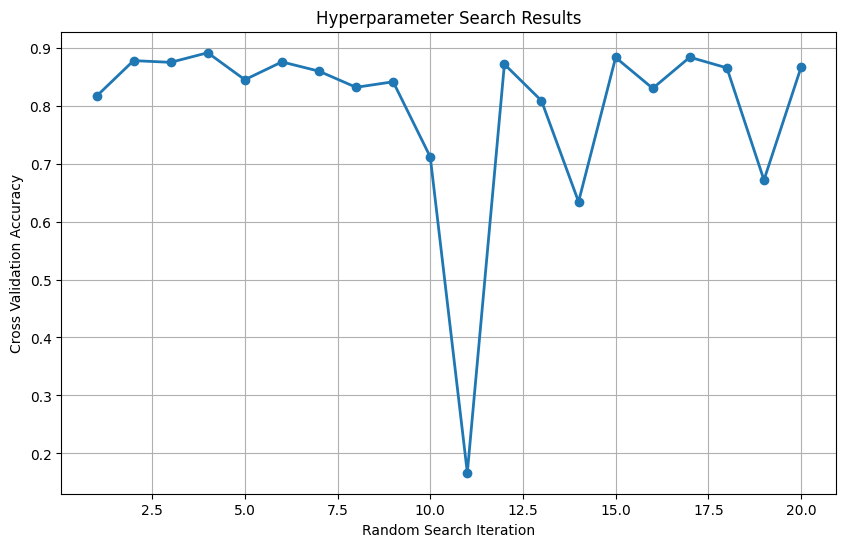

In [72]:
results = random_search.cv_results_
mean_scores = results["mean_test_score"]
iteration_numbers = np.arange(1, len(mean_scores) + 1)
plt.figure(figsize=(10,6))
plt.plot(
    iteration_numbers,
    mean_scores,
    marker="o",
    linewidth=2,)
plt.xlabel("Random Search Iteration")
plt.ylabel("Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")
plt.grid(True)
save_plot("plots/hyperparameter_search_results.png")
plt.show()

In [73]:
ranking = np.argsort(mean_scores)[::-1]
for rank, index in enumerate(ranking[:10], start=1):
    print(f"\nRank {rank}")
    print(f"Accuracy : {mean_scores[index]:.4f}")
    print(results["params"][index])


Rank 1
Accuracy : 0.8911
{'model__optimizer': 'sgd', 'model__neurons': 128, 'model__learning_rate': 0.1, 'model__hidden_layers': 1, 'model__dropout_rate': 0.0, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}

Rank 2
Accuracy : 0.8833
{'model__optimizer': 'rmsprop', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'sigmoid', 'epochs': 20, 'batch_size': 128}

Rank 3
Accuracy : 0.8828
{'model__optimizer': 'rmsprop', 'model__neurons': 64, 'model__learning_rate': 0.001, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'sigmoid', 'epochs': 20, 'batch_size': 16}

Rank 4
Accuracy : 0.8774
{'model__optimizer': 'rmsprop', 'model__neurons': 128, 'model__learning_rate': 0.001, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'sigmoid', 'epochs': 10, 'batch_size': 16}

Rank 5
Accuracy : 0.8752
{'model__optimizer': 'sgd', 'model__neurons': 256, 'model__

**optimized_model**

In [74]:
optimized_model = build_model(
    hidden_layers=best_hidden_layers,
    neurons=best_neurons,
    learning_rate=best_learning_rate,
    optimizer=best_optimizer,
    activation=best_activation,
    dropout_rate=best_dropout,
)
optimized_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
optimized_start = time.time()
optimized_history = optimized_model.fit(
    x_train_flat,
    y_train_cat,
    epochs=best_epochs,
    batch_size=best_batch_size,
    validation_split=0.2,
    verbose=1,
)
optimized_training_time = time.time() - optimized_start
print("\nOptimized Training Time : %.2f seconds" %optimized_training_time)


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8036 - loss: 0.5429 - val_accuracy: 0.8456 - val_loss: 0.4390
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8476 - loss: 0.4205 - val_accuracy: 0.8580 - val_loss: 0.4024
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8609 - loss: 0.3834 - val_accuracy: 0.8638 - val_loss: 0.3817
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8693 - loss: 0.3585 - val_accuracy: 0.8692 - val_loss: 0.3673
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8755 - loss: 0.3396 - val_accuracy: 0.8724 - val_loss: 0.3558
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8806 - loss: 0.3241 - val_accuracy: 0.8763 - val_loss: 0.3466
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8851 - loss: 0.3110 - val_accuracy: 0.8785 - val_loss: 0.3403
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8884 - loss: 0.2996 - 

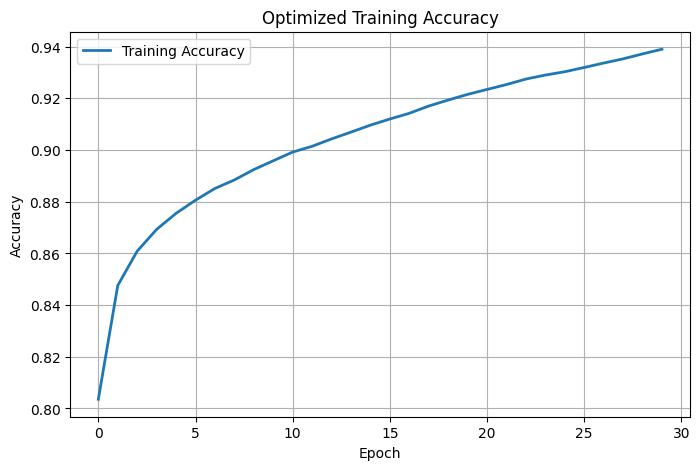

In [76]:
plt.figure(figsize=(8,5))
plt.plot(
    optimized_history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Optimized Training Accuracy")
plt.grid(True)
plt.legend()
save_plot("plots/optimized_training_accuracy.png")
plt.show()

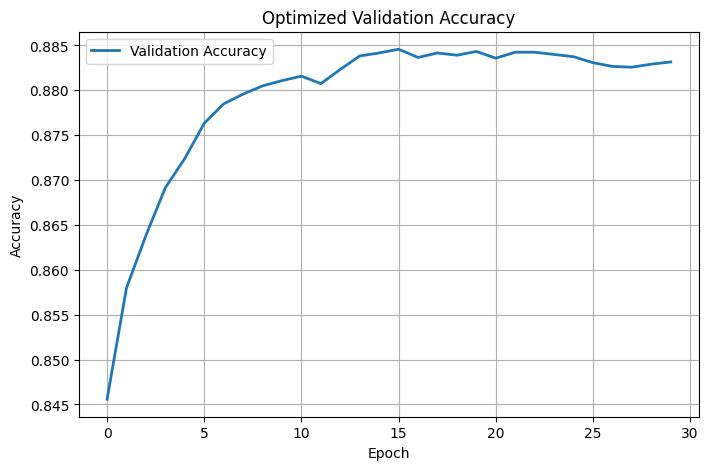

In [77]:
plt.figure(figsize=(8,5))
plt.plot(
    optimized_history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Optimized Validation Accuracy")
plt.grid(True)
plt.legend()
save_plot("plots/optimized_validation_accuracy.png")
plt.show()

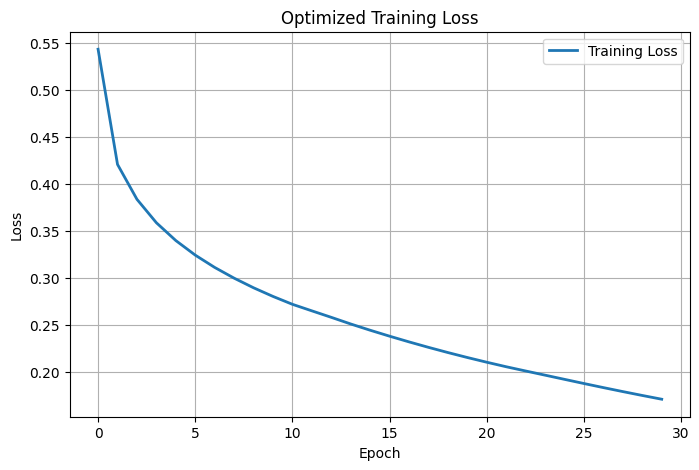

In [78]:
plt.figure(figsize=(8,5))
plt.plot(
    optimized_history.history["loss"],
    linewidth=2,
    label="Training Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimized Training Loss")
plt.grid(True)
plt.legend()
save_plot("plots/optimized_training_loss.png")
plt.show()

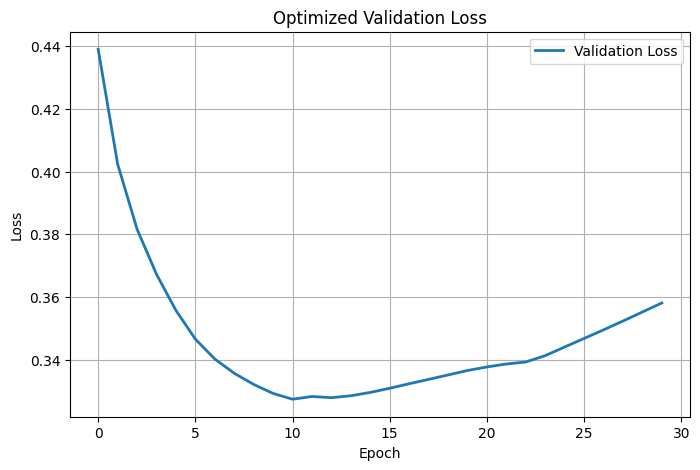

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    optimized_history.history["val_loss"],
    linewidth=2,
    label="Validation Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimized Validation Loss")
plt.grid(True)
plt.legend()
save_plot("plots/optimized_validation_loss.png")
plt.show()

In [80]:
loss, accuracy = optimized_model.evaluate(
    x_test_flat,
    y_test_cat,
    verbose=0,
)
print(f"\nTesting Accuracy : {accuracy:.4f}")


Testing Accuracy : 0.8737


In [81]:
optimized_probabilities = optimized_model.predict(x_test_flat)
optimized_predictions = np.argmax(
    optimized_probabilities,
    axis=1,
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [82]:
optimized_accuracy = accuracy_score(y_test,optimized_predictions,)
optimized_precision = precision_score(y_test,optimized_predictions,average="weighted",)
optimized_recall = recall_score( y_test, optimized_predictions, average="weighted",)
optimized_f1 = f1_score(  y_test,optimized_predictions,average="weighted",)

In [83]:
print(f"Accuracy  : {optimized_accuracy:.4f}")
print(f"Precision : {optimized_precision:.4f}")
print(f"Recall    : {optimized_recall:.4f}")
print(f"F1 Score  : {optimized_f1:.4f}")

Accuracy  : 0.8737
Precision : 0.8763
Recall    : 0.8737
F1 Score  : 0.8739


In [84]:
print("Classification Report\n")
print( classification_report(
        y_test,
        optimized_predictions,
        target_names=CLASS_NAMES,))


Classification Report

              precision    recall  f1-score   support

     T-shirt       0.88      0.76      0.81      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.73      0.84      0.78      1000
       Dress       0.87      0.88      0.88      1000
        Coat       0.80      0.79      0.80      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.69      0.69      0.69      1000
     Sneaker       0.90      0.97      0.94      1000
         Bag       0.96      0.97      0.96      1000
  Ankle Boot       0.97      0.92      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



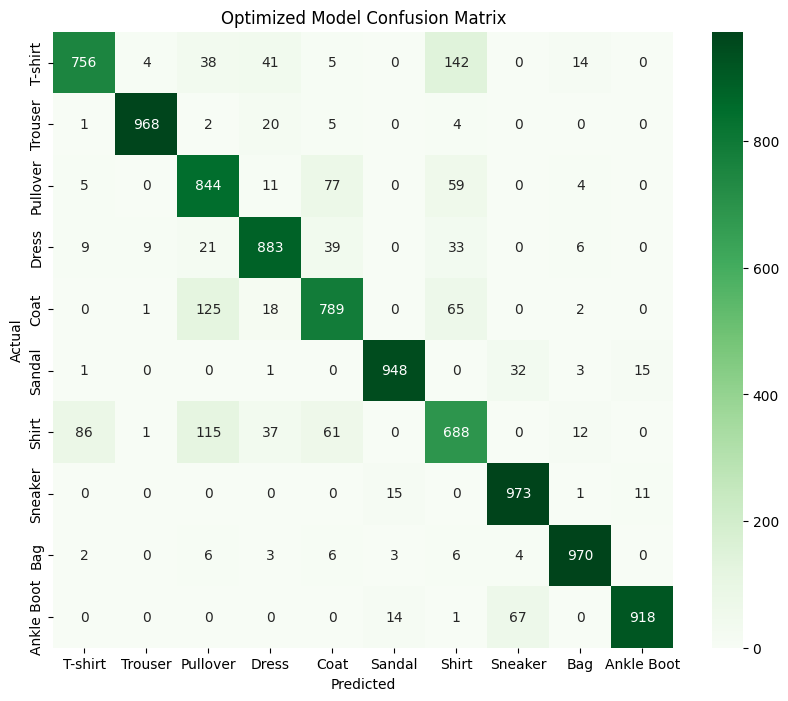

In [85]:
optimized_cm = confusion_matrix(
    y_test,
    optimized_predictions,
)
plt.figure(figsize=(10,8))
sns.heatmap(
    optimized_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized Model Confusion Matrix")
save_plot("plots/optimized_confusion_matrix.png")
plt.show()

In [86]:
performance = {

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)",
    ],

    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_training_time,
    ],

    "Optimized": [
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1,
        optimized_training_time,
    ],

}

performance_df = pd.DataFrame(performance)
print("\nPerformance Comparison")
print(performance_df)


Performance Comparison
              Metric   Baseline   Optimized
0           Accuracy   0.876000    0.873700
1          Precision   0.878725    0.876331
2             Recall   0.876000    0.873700
3           F1 Score   0.876489    0.873928
4  Training Time (s)  89.055140  131.150079


In [87]:
performance_df.to_csv(
    "performance_comparison.csv",
    index=False,
)

In [88]:
print(f"Hidden Layers        : {best_hidden_layers}")
print(f"Hidden Neurons       : {best_neurons}")
print(f"Learning Rate        : {best_learning_rate}")
print(f"Batch Size           : {best_batch_size}")
print(f"Epochs               : {best_epochs}")
print(f"Optimizer            : {best_optimizer}")
print(f"Activation Function  : {best_activation}")
print(f"Dropout Rate         : {best_dropout}")
print(f"Cross Validation Acc : {best_cv_accuracy:.4f}")
print(f"Testing Accuracy     : {optimized_accuracy:.4f}")

Hidden Layers        : 1
Hidden Neurons       : 128
Learning Rate        : 0.1
Batch Size           : 32
Epochs               : 30
Optimizer            : sgd
Activation Function  : tanh
Dropout Rate         : 0.0
Cross Validation Acc : 0.8911
Testing Accuracy     : 0.8737


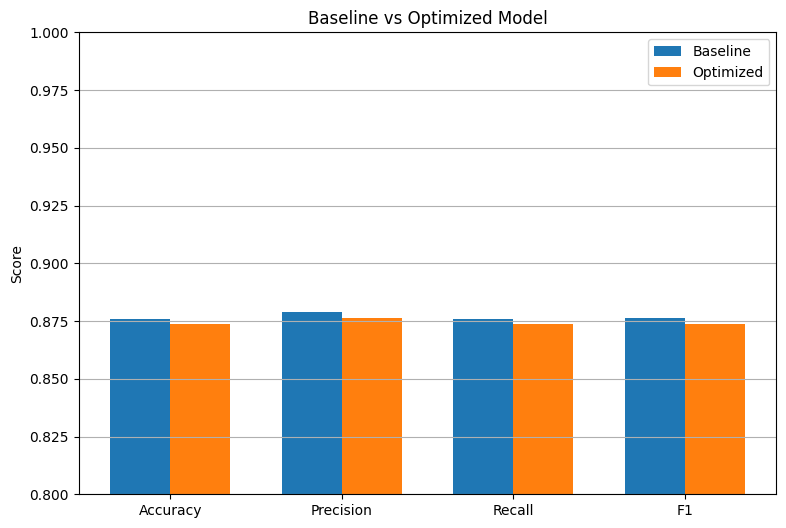

In [89]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
]

baseline_scores = [
    baseline_accuracy,
    baseline_precision,
    baseline_recall,
    baseline_f1,
]

optimized_scores = [
    optimized_accuracy,
    optimized_precision,
    optimized_recall,
    optimized_f1,
]

x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(9,6))
plt.bar(
    x-width/2,
    baseline_scores,
    width,
    label="Baseline",
)

plt.bar(
    x+width/2,
    optimized_scores,
    width,
    label="Optimized",
)

plt.xticks(
    x,
    metrics,
)
plt.ylim(0.8,1.0)
plt.ylabel("Score")
plt.title("Baseline vs Optimized Model")
plt.legend()
plt.grid(axis="y")
save_plot("plots/accuracy_comparison.png")
plt.show()

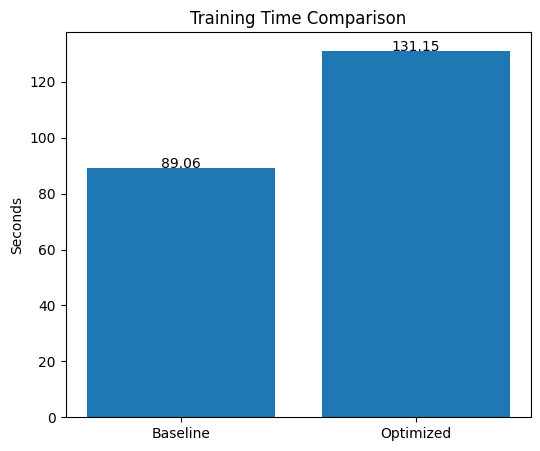

In [90]:
plt.figure(figsize=(6,5))
times = [
    baseline_training_time,
    optimized_training_time,
]
labels = [
    "Baseline",
    "Optimized",
]
plt.bar(
    labels,
    times,
)
plt.ylabel("Seconds")
plt.title("Training Time Comparison")
for i,v in enumerate(times):
    plt.text(
        i,
        v,
        f"{v:.2f}",
        ha="center",
    )
save_plot("plots/training_time_comparison.png")
plt.show()

In [94]:
os.makedirs("models", exist_ok=True)

In [95]:
optimized_model.save("models/best_mlp.keras")
print("\nBest model saved successfully.")


Best model saved successfully.


In [96]:
results = pd.DataFrame({
    "Parameter":[
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Epochs",
        "Optimizer",
        "Activation",
        "Dropout",
        "Cross Validation Accuracy",
        "Testing Accuracy",
    ],
    "Value":[
        best_hidden_layers,
        best_neurons,
        best_learning_rate,
        best_batch_size,
        best_epochs,
        best_optimizer,
        best_activation,
        best_dropout,
        round(best_cv_accuracy,4),
        round(optimized_accuracy,4),
    ]
})
print(results)
results.to_csv("best_hyperparameters.csv",index=False)


                   Parameter   Value
0              Hidden Layers       1
1             Hidden Neurons     128
2              Learning Rate     0.1
3                 Batch Size      32
4                     Epochs      30
5                  Optimizer     sgd
6                 Activation    tanh
7                    Dropout     0.0
8  Cross Validation Accuracy  0.8911
9           Testing Accuracy  0.8737


In [97]:
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print(f"Baseline Accuracy   : {baseline_accuracy:.4f}")
print(f"Optimized Accuracy  : {optimized_accuracy:.4f}")
print(f"Improvement         : {(optimized_accuracy-baseline_accuracy):.4f}")
print()
if optimized_accuracy > baseline_accuracy:
    print("Hyperparameter optimization improved the model.")
elif optimized_accuracy == baseline_accuracy:
    print("Both models achieved identical performance.")
else:
    print("Baseline model performed better.")
print()
print(f"Best Optimizer      : {best_optimizer}")
print(f"Best Activation     : {best_activation}")
print(f"Best Learning Rate  : {best_learning_rate}")
print(f"Best Hidden Layers  : {best_hidden_layers}")
print(f"Best Neurons        : {best_neurons}")
print(f"Best Batch Size     : {best_batch_size}")
print(f"Best Epochs         : {best_epochs}")
print(f"Best Dropout        : {best_dropout}")
print()
print("Plots saved in : plots/")
print("Model saved in : models/")

EXPERIMENT COMPLETED SUCCESSFULLY
Baseline Accuracy   : 0.8760
Optimized Accuracy  : 0.8737
Improvement         : -0.0023

Baseline model performed better.

Best Optimizer      : sgd
Best Activation     : tanh
Best Learning Rate  : 0.1
Best Hidden Layers  : 1
Best Neurons        : 128
Best Batch Size     : 32
Best Epochs         : 30
Best Dropout        : 0.0

Plots saved in : plots/
Model saved in : models/
